## Exploratory Data Analysis (EDA)

### Objective
To explore the METABRIC breast cancer dataset and understand:
- data distribution
- survival characteristics
- clinical feature impact on survival

This step prepares the dataset for survival modeling.

In [4]:
# 1. 라이브러리 import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [5]:
# 2. 데이터 로드
file_path = "../data/raw/brca_metabric_clinical_data.tsv"

df = pd.read_csv(file_path, sep="\t")

print("Shape:", df.shape)
df.head()

Shape: (2509, 39)


,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,YES,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,0:LIVING,Negative,YES,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,YES,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,0:LIVING,Positive,YES,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,YES,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,1:DECEASED,Positive,NO,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease
3,brca_metabric,MB-0006,MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,YES,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,0:LIVING,Positive,YES,164.933333,0:Not Recurred,1,Primary,Female,NaN,1.307518,25.0,2.0,Living
4,brca_metabric,MB-0008,MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,YES,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,1:DECEASED,Positive,YES,18.800000,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0,Died of Disease


In [7]:
# 3. target 변수 생성
df["event"] = df["Patient's Vital Status"].apply(
    lambda x: 1 if x == "Died of Disease" else 0
)

df["time"] = pd.to_numeric(df["Overall Survival (Months)"], errors = "coerce")

df[["Patient's Vital Status", "event", "time"]].head()

,Patient's Vital Status,event,time
0,Living,0,140.500000
1,Living,0,84.633333
2,Died of Disease,1,163.700000
3,Living,0,164.933333
4,Died of Disease,1,41.366667


In [8]:
# 4. feature 선택
selected_features = [
    "Age at Diagnosis",
    "Neoplasm Histologic Grade",
    "Tumor Stage",
    "ER Status",
    "HER2 Status",
    "Lymph nodes examined positive",
    "Tumor Size",
    "time",
    "event",
]

df_model = df[selected_features].copy()
print("Before dropna:", df_model.shape)

df_model = df_model.dropna()
print("After dropna:", df_model.shape)

df_model.head()

Before dropna: (2509, 9)
After dropna: (1354, 9)


,Age at Diagnosis,Neoplasm Histologic Grade,Tumor Stage,ER Status,HER2 Status,Lymph nodes examined positive,Tumor Size,time,event
0,75.65,3.0,2.0,Positive,Negative,10.0,22.0,140.500000,0
1,43.19,3.0,1.0,Positive,Negative,0.0,10.0,84.633333,0
2,48.87,2.0,2.0,Positive,Negative,1.0,15.0,163.700000,1
3,47.68,2.0,2.0,Positive,Negative,3.0,25.0,164.933333,0
4,76.97,3.0,2.0,Positive,Negative,8.0,40.0,41.366667,1


In [9]:
# 5. 기본 구조 확인
df_model.info()

df_model.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1354 entries, 0 to 1743
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age at Diagnosis               1354 non-null   float64
 1   Neoplasm Histologic Grade      1354 non-null   float64
 2   Tumor Stage                    1354 non-null   float64
 3   ER Status                      1354 non-null   object 
 4   HER2 Status                    1354 non-null   object 
 5   Lymph nodes examined positive  1354 non-null   float64
 6   Tumor Size                     1354 non-null   float64
 7   time                           1354 non-null   float64
 8   event                          1354 non-null   int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 105.8+ KB


,Age at Diagnosis,Neoplasm Histologic Grade,Tumor Stage,Lymph nodes examined positive,Tumor Size,time,event
count,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000
mean,60.405428,2.437223,1.756278,1.895864,25.857829,127.136928,0.338257
std,12.990900,0.644015,0.624442,3.925613,14.965861,78.024751,0.473291
min,21.930000,1.000000,0.000000,0.000000,1.000000,0.100000,0.000000
25%,50.712500,2.000000,1.000000,0.000000,17.000000,61.500000,0.000000
50%,61.020000,3.000000,2.000000,0.000000,22.000000,116.783333,0.000000
75%,69.790000,3.000000,2.000000,2.000000,30.000000,187.908333,1.000000
max,96.290000,3.000000,4.000000,41.000000,180.000000,351.000000,1.000000


In [10]:
# 6. 결측치 확인
df[selected_features].isnull().sum().sort_values(ascending=False)

Tumor Stage                      721
HER2 Status                      529
time                             528
Lymph nodes examined positive    266
Tumor Size                       149
Neoplasm Histologic Grade        121
ER Status                         40
Age at Diagnosis                  11
event                              0
dtype: int64

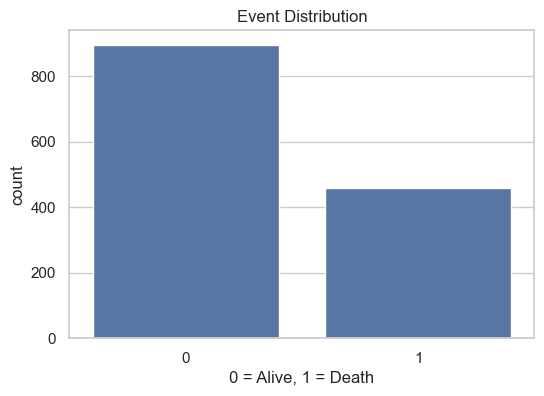

In [11]:
# 7. event 분포
df_model["event"].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x="event", data=df_model)
plt.title("Event Distribution")
plt.xlabel("0 = Alive, 1 = Death")
plt.show()

#### 해석: Event 분포

환자의 생존 여부(event) 분포를 확인한 결과, 생존(0)과 사망(1) 클래스가 완전히 균형적이지는 않지만, 생존분석을 수행하기에는 충분한 사건(event) 수가 존재한다.

이 결과는 다음을 시사한다.

- METABRIC 데이터는 overall survival 분석에 적합한 구조를 가진다.
- event 불균형이 존재할 수 있으므로, 이후 모델 해석에서는 단순 정확도보다  
  
  생존곡선, hazard ratio, concordance index와 같은 survival-specific metric이 중요하다.
- 사망(event=1) 환자 비율은 실제 임상 데이터의 특성을 반영하며, 이는 현실적인 risk modeling 환경을 제공한다.

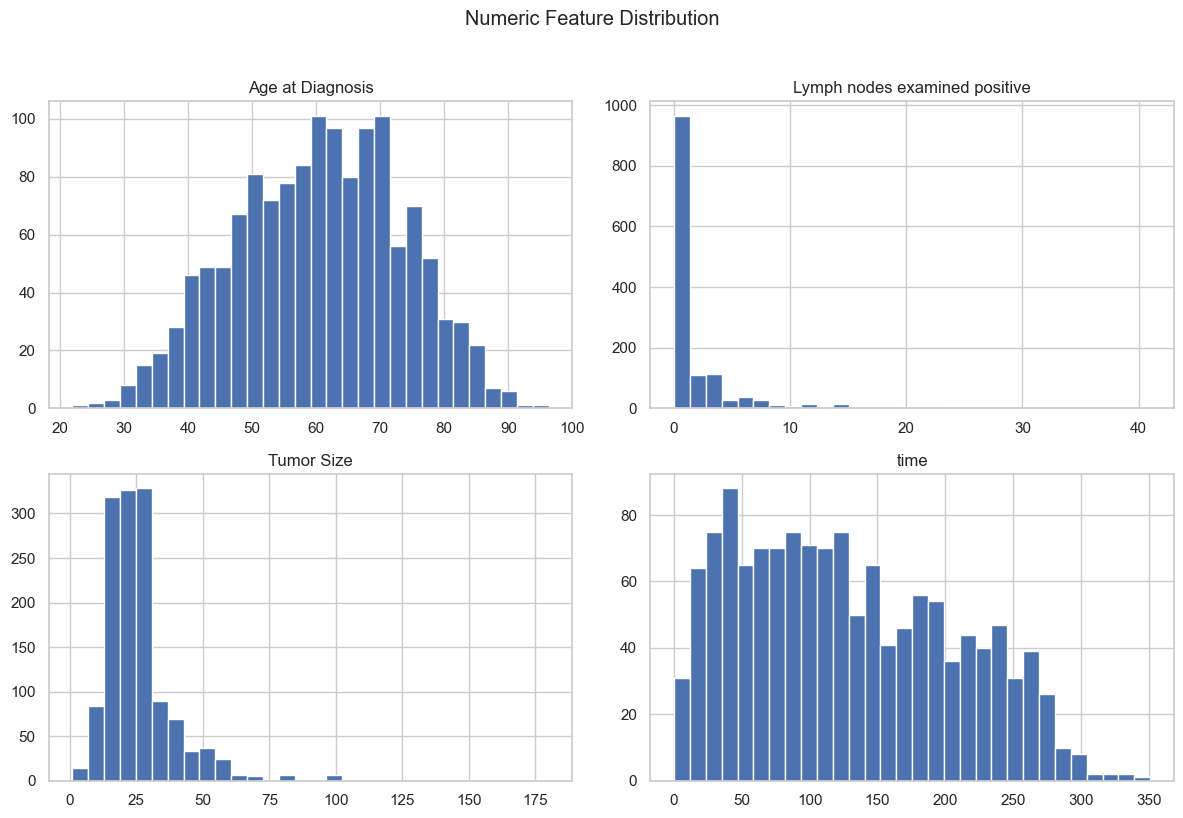

In [12]:
# 8. 수치형 변수 분포
numeric_cols = [
    "Age at Diagnosis",
    "Lymph nodes examined positive",
    "Tumor Size",
    "time"
]

df_model[numeric_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Numeric Feature Distribution", y=1.02)
plt.tight_layout()
plt.show()

#### 해석: 수치형 변수 분포

연령, 양성 림프절 수, 종양 크기, 생존기간(time)의 분포를 확인하였다.

주요 해석은 다음과 같다.

- **Age at Diagnosis**는 비교적 넓은 범위에 분포하며, 고령 환자군에서 생존 위험이 증가할 가능성을 탐색할 수 있다.
- **Lymph nodes examined positive**는 오른쪽으로 치우친 분포를 보일 가능성이 높으며, 일부 환자에서 높은 림프절 전이 수가 관찰된다.
- **Tumor Size** 역시 종양 진행 정도와 연관될 수 있는 핵심 임상 변수다.
- **time** 변수는 환자별 생존기간 차이를 보여주며, 생존분석 모델에서 핵심 target 축으로 사용된다.

이러한 분포는 이후 단계에서 이상치, 로그 변환 필요성, 임상적 cut-off 설정 가능성을 검토하는 근거가 된다.

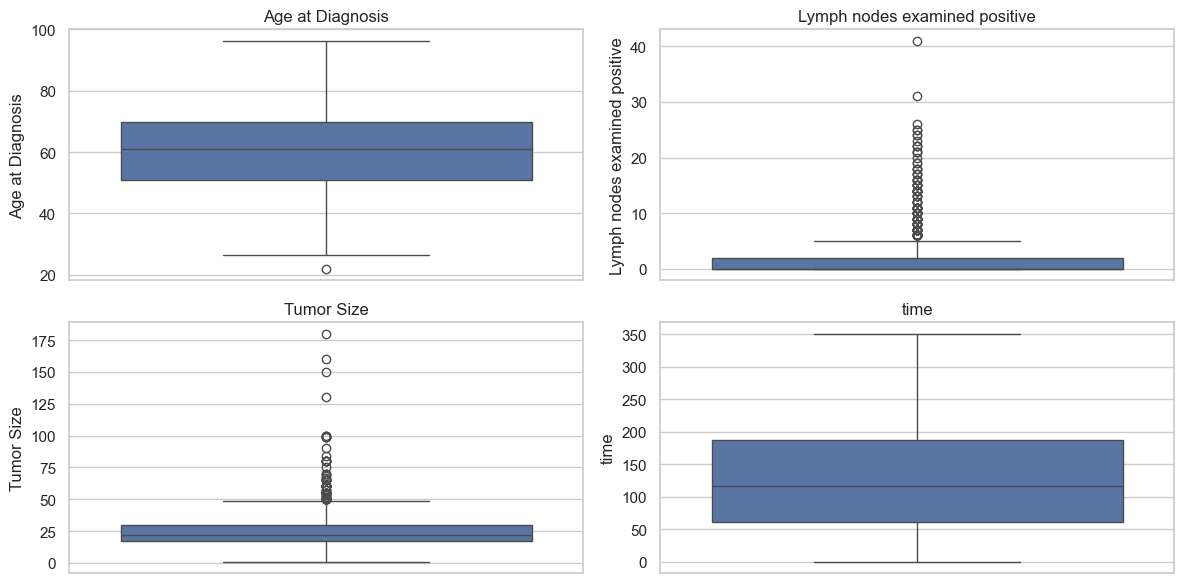

In [13]:
# 9. 이상치 확인 (Boxplot)
plt.figure(figsize=(12,6))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=df_model[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### 해석: 이상치 및 분포 특성

Boxplot을 통해 수치형 변수의 이상치 및 분포 특성을 확인하였다.

주요 관찰 포인트는 다음과 같다.

- **Lymph nodes examined positive**는 일부 환자에서 매우 높은 값을 가지며, 이는 고위험군을 반영할 수 있다.
- **Tumor Size** 또한 큰 종양 크기를 가진 일부 환자가 존재할 수 있으며, 이는 생존 위험 증가와 연결될 가능성이 있다.
- survival analysis에서는 모든 극단값을 단순 제거하기보다, 임상적으로 의미 있는 high-risk subgroup인지 먼저 판단하는 것이 중요하다.

따라서 이후 feature engineering 단계에서는 이상치를 제거하는 방식보다는 임상적 해석 가능성을 유지하는 방향으로 접근한다.

In [14]:
# 10. 범주형 변수 분포
categorical_cols = [
    "Neoplasm Histologic Grade",
    "Tumor Stage",
    "ER Status",
    "HER2 Status"
]

for col in categorical_cols:
    print(f"\n{col}]")
    print(df_model[col].value_counts())


Neoplasm Histologic Grade]
Neoplasm Histologic Grade
3.0    706
2.0    534
1.0    114
Name: count, dtype: int64

Tumor Stage]
Tumor Stage
2.0    776
1.0    457
3.0    111
4.0      9
0.0      1
Name: count, dtype: int64

ER Status]
ER Status
Positive    1041
Negative     313
Name: count, dtype: int64

HER2 Status]
HER2 Status
Negative    1186
Positive     168
Name: count, dtype: int64


#### 해석: 범주형 변수 분포

주요 범주형 변수(Grade, Tumor Stage, ER Status, HER2 Status)의 분포를 확인하였다.

이 결과는 다음과 같은 의미를 가진다.

- **Neoplasm Histologic Grade**는 종양의 조직학적 악성도를 나타내며, 높은 grade일수록 예후가 나쁠 가능성이 있다.
- **Tumor Stage**는 종양 진행 정도를 반영하는 대표 변수로, survival outcome과의 관련성이 높을 것으로 예상된다.
- **ER Status**, **HER2 Status**는 유방암의 분자적 특성과 치료 전략에 직접 연결되므로, 생존 차이를 설명하는 중요한 임상 변수다.

이러한 범주형 변수는 Kaplan-Meier curve 비교와 Cox PH 모델의 hazard ratio 해석에서 핵심 역할을 하게 된다.

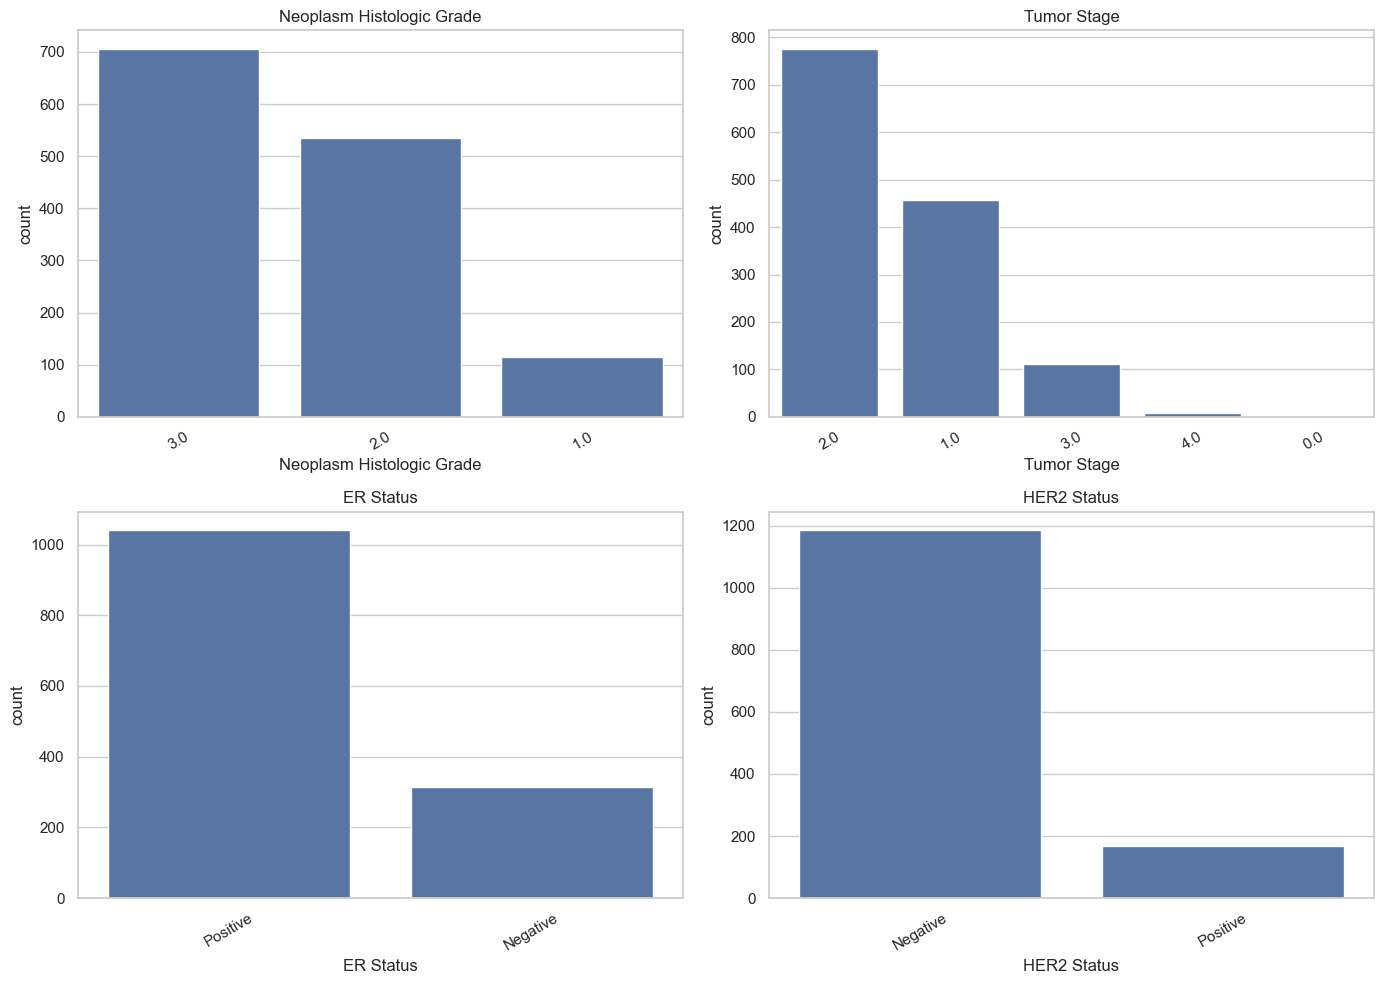

In [15]:
# 11. 범주형 시각화
fig, axes = plt.subplots(2,2, figsize=(14,10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df_model, x=col, ax=ax, order=df_model[col].value_counts().index)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

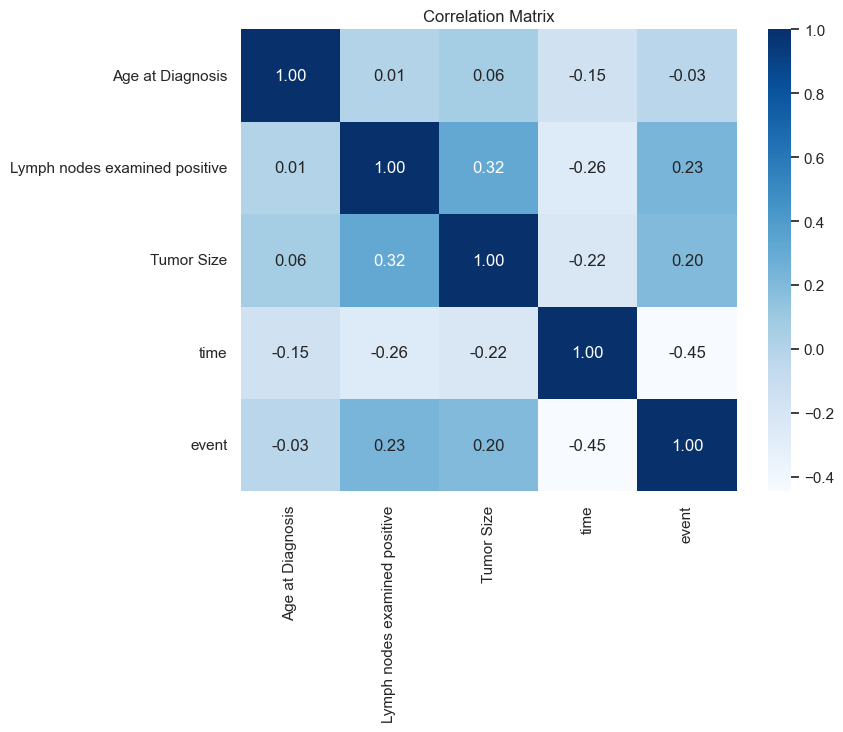

In [16]:
# 12. 상관관계

corr = df_model[numeric_cols + ["event"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#### 해석: 수치형 변수 상관관계

수치형 변수 간 상관관계를 확인한 결과, 일부 변수들은 서로 약하거나 중간 정도의 상관성을 보일 수 있다.

주요 의미는 다음과 같다.

- **Lymph nodes examined positive**와 **Tumor Stage** 또는 **Tumor Size**는 암 진행 정도와 관련되어 일정 수준의 연관성을 보일 수 있다.
- **event**와 직접적인 단순 상관계수는 제한적일 수 있으나,  
  
  survival outcome은 time-to-event 구조이므로 Cox PH와 같은 survival 모델에서 더 정교하게 해석하는 것이 적절하다.
- 상관관계가 지나치게 높은 변수 조합이 존재하는 경우,  
  
  이후 모델링 단계에서 다중공선성(multicollinearity)을 검토할 필요가 있다.

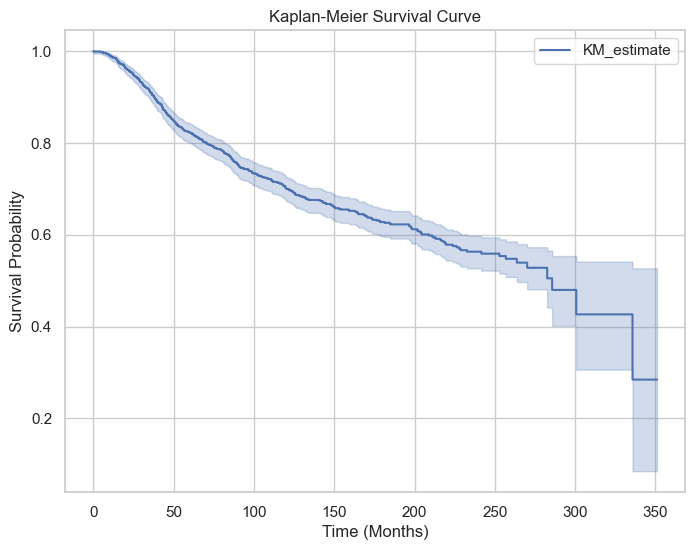

In [17]:
# 13. Kaplan-Meier (전체 생존곡선)
kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))
kmf.fit(df_model["time"], event_observed=df_model["event"])
kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.show()

#### 해석: 전체 Kaplan-Meier 생존곡선

전체 환자군의 Kaplan-Meier 생존곡선을 통해 시간에 따른 생존확률 변화를 확인하였다.

주요 해석은 다음과 같다.

- 시간이 지남에 따라 생존확률이 점진적으로 감소하는 패턴이 관찰된다.
- 곡선의 하강 구간은 사건(event, 사망)이 발생한 시점을 반영한다.
- 이 결과는 METABRIC 데이터가 survival analysis 수행에 적합하며, 전체 환자군 차원의 기본 생존 패턴을 제공한다.

이 곡선은 이후 ER, HER2, Tumor Stage 등 임상 변수별 subgroup survival curve와 비교할 기준선 역할을 한다.

---

#### Interpretation (English Summary)

The Kaplan-Meier curve shows a gradual decline in survival probability over time, indicating a consistent occurrence of events (death) across the cohort.

This curve serves as a baseline reference for comparing subgroup survival differences in subsequent analyses.

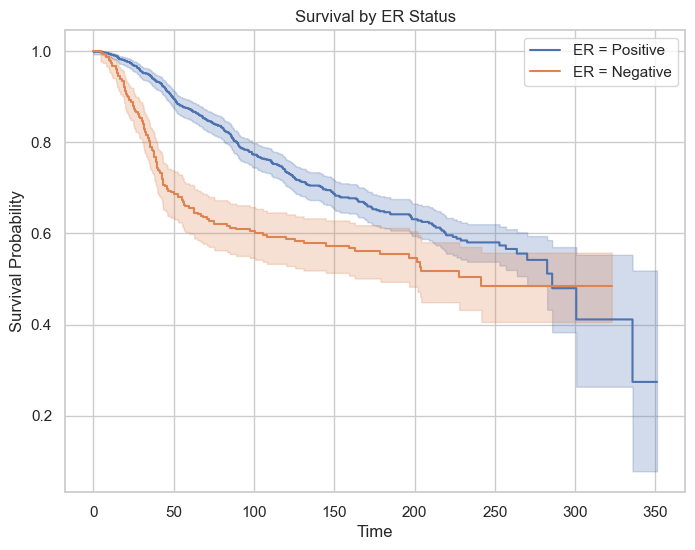

In [18]:
# 14. ER Status별 survival
plt.figure(figsize=(8,6))

for status in df_model["ER Status"].unique():
    mask = df_model["ER Status"] == status
    
    kmf.fit(
        df_model.loc[mask, "time"],
        df_model.loc[mask, "event"],
        label=f"ER = {status}"
    )
    kmf.plot_survival_function()

plt.title("Survival by ER Status")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

#### 해석: ER Status에 따른 생존 차이

ER Status 그룹별 Kaplan-Meier 곡선을 비교함으로써 에스트로겐 수용체 상태에 따른 생존 패턴 차이를 확인하였다.

주요 의미는 다음과 같다.

- ER 양성/음성 여부에 따라 생존곡선의 분리가 나타난다면, 해당 변수가 환자 예후에 중요한 영향을 줄 가능성이 있다.
- 이는 ER Status가 단순 분자적 분류 변수를 넘어 실제 survival outcome과 관련된 임상적 예측 변수임을 시사한다.
- 이후 Cox PH 모델에서 hazard ratio를 통해 ER Status의 정량적 위험도를 해석할 수 있다.

---

#### Interpretation (English Summary)

The survival curves stratified by ER status show a noticeable separation between groups, suggesting that ER status is a significant prognostic factor.

This indicates its strong relevance for inclusion in downstream survival models such as Cox PH.

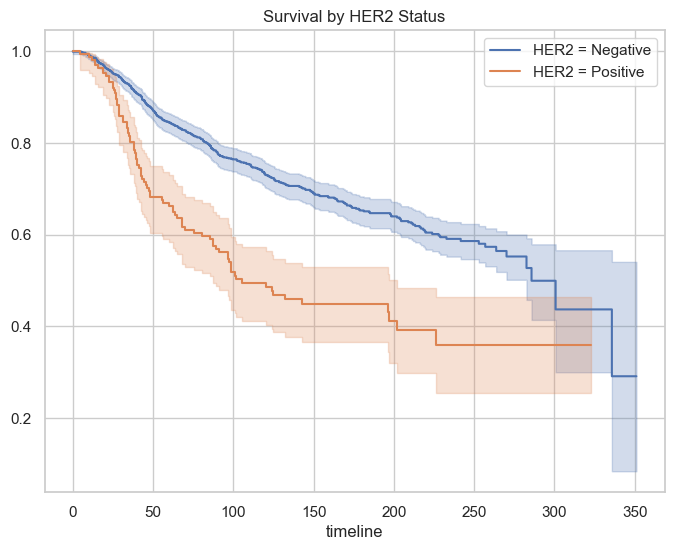

In [19]:
# 15. HER2 Status별 survival
plt.figure(figsize=(8,6))

for status in df_model["HER2 Status"].unique():
    mask = df_model["HER2 Status"] == status
    
    kmf.fit(
        df_model.loc[mask, "time"],
        df_model.loc[mask, "event"],
        label=f"HER2 = {status}"
    )
    kmf.plot_survival_function()

plt.title("Survival by HER2 Status")
plt.show()

#### 해석: HER2 Status에 따른 생존 차이

HER2 Status 그룹별 생존곡선을 비교하여 분자 아형에 따른 예후 차이를 탐색하였다.

주요 해석은 다음과 같다.

- HER2 상태에 따라 생존곡선이 분리된다면, 해당 변수가 생존 위험을 설명하는 유의미한 clinical feature일 가능성이 있다.
- HER2는 치료 전략과도 밀접하게 연결되는 변수이므로, 단순 통계적 차이를 넘어 임상적 해석 가치가 높다.
- 이후 모델링에서는 HER2 Status를 핵심 범주형 변수로 포함하여 위험도 추정을 수행할 수 있다.

---

#### Interpretation (English Summary)

Differences in survival curves across HER2 status groups suggest potential prognostic significance, although further statistical validation is required.

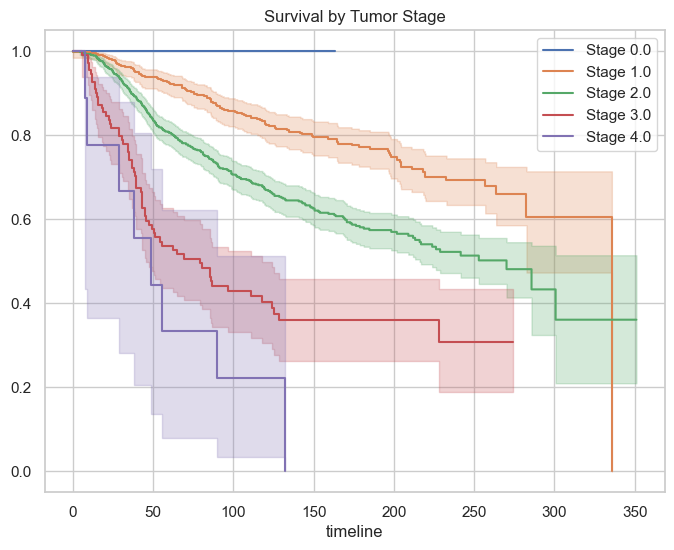

In [20]:
# 16. Tumor Stage별 survival
plt.figure(figsize=(8,6))

for stage in sorted(df_model["Tumor Stage"].astype(str).unique()):
    mask = df_model["Tumor Stage"].astype(str) == stage
    
    kmf.fit(
        df_model.loc[mask, "time"],
        df_model.loc[mask, "event"],
        label=f"Stage {stage}"
    )
    kmf.plot_survival_function()

plt.title("Survival by Tumor Stage")
plt.show()

#### 해석: Tumor Stage에 따른 생존 차이

Tumor Stage별 Kaplan-Meier 곡선을 비교한 결과, 병기(stage)가 높아질수록 더 낮은 생존확률을 보일 가능성이 있다.

주요 의미는 다음과 같다.

- Tumor Stage는 질병 진행 정도를 직접적으로 반영하는 핵심 임상 변수다.
- Stage 간 생존곡선 분리가 뚜렷하다면, 해당 변수는 survival prediction에서 매우 강한 설명력을 가질 수 있다.
- 이는 이후 Cox PH 모델에서 hazard ratio 해석의 중심 변수가 될 가능성이 높다.

따라서 Tumor Stage는 feature engineering과 modeling 단계에서 우선적으로 유지해야 할 핵심 변수다.

---

#### Interpretation (English Summary)

Survival probability decreases as tumor stage increases, demonstrating a clear stage-dependent survival pattern.

Tumor stage appears to be a highly influential clinical variable and is expected to play a key role in survival prediction models.

## EDA 종합 요약

이번 EDA를 통해 다음을 확인하였다.

- METABRIC 데이터는 survival analysis에 적합한 구조를 가진다.
- time과 event 변수가 성공적으로 정의되었다.
- 주요 임상 변수들은 생존 결과와 관련된 유의미한 패턴을 보일 가능성이 있다.
- ER Status, HER2 Status, Tumor Stage는 subgroup survival 비교에서 핵심 변수다.
- 수치형 변수 일부는 이상치와 비대칭 분포를 가지므로, 이후 feature engineering에서 추가 정리가 필요하다.

다음 단계에서는:
1. 범주형 변수 인코딩
2. 수치형 변수 정리
3. Cox Proportional Hazards 모델링
을 진행한다.

---

## EDA Summary (English Version)

This exploratory data analysis confirms that the METABRIC dataset is suitable for survival modeling tasks.

Key findings include:

- Proper construction of survival variables (`time`, `event`) enables time-to-event analysis.
- Clinically relevant variables such as **ER Status**, **HER2 Status**, and **Tumor Stage** demonstrate potential impact on patient survival.
- Distributional characteristics of numerical features indicate the presence of skewness and outliers, which require careful handling.
- Kaplan-Meier analysis reveals meaningful differences across clinical subgroups, supporting their inclusion in downstream modeling.

### Next Steps

The subsequent phase will focus on:

1. Feature engineering (categorical encoding and numerical transformation)
2. Data preprocessing and quality refinement
3. Survival modeling using Cox Proportional Hazards and evaluation via concordance index